In [1]:
# Install MuJoCo physics engine + Gymnasium
# mujoco: physics simulator for Hopper, HalfCheetah, etc.
# gymnasium[mujoco]: wraps MuJoCo environments in Gym API
!pip install -q "gymnasium[mujoco]" mujoco torch numpy matplotlib
print("Done")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 13.8 MB/s eta 0:00:00
Done


In [2]:
import os, json, time, copy, math
from pathlib import Path
from collections import deque

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import gymnasium as gym
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Device ────────────────────────────────────────────────────────────────────
# TD3 networks are small MLPs — GPU helps but CPU is acceptable
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(SEED)
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

# ── Verify Gymnasium + MuJoCo ─────────────────────────────────────────────────
env_test = gym.make("Hopper-v5")
obs, _   = env_test.reset(seed=SEED)
print(f"\nHopper-v5 verified:")
print(f"  Observation space : {env_test.observation_space}")
print(f"  Action space      : {env_test.action_space}")
print(f"  Obs shape         : {obs.shape}")
env_test.close()

Device : cuda
GPU    : Tesla T4

Hopper-v5 verified:
  Observation space : Box(-inf, inf, (11,), float64)
  Action space      : Box(-1.0, 1.0, (3,), float32)
  Obs shape         : (11,)


In [3]:
CFG = {
    # Environment
    "env_name"           : "Hopper-v5",
    "seed"               : 42,

    # Training
    "total_steps"        : 300_000,   # total env steps
    "warmup_steps"       : 25_000,      # random actions before training starts
    "batch_size"         : 256,
    "discount"           : 0.99,        # γ  — future reward discount

    # Networks
    "hidden_dim"         : 256,         # MLP hidden size for actor and critic
    "actor_lr"           : 3e-4,
    "critic_lr"          : 3e-4,

    # TD3 specific
    "tau"                : 0.005,       # Polyak averaging coefficient
    "policy_noise"       : 0.2,         # σ for target policy smoothing
    "noise_clip"         : 0.5,         # clip range c for target noise
    "policy_delay"       : 2,           # update actor every N critic steps
    "expl_noise"         : 0.1,         # σ for exploration noise during training

    # Replay buffer
    "buffer_size"        : 1_000_000,

    # Evaluation
    "eval_every"         : 10_000,       # evaluate every N steps
    "eval_episodes"      : 10,          # number of deterministic eval episodes

    # Logging & saving
    "log_every"          : 1_000,
    "save_dir"           : "./checkpoints_rl",
}

print("TD3 Hyperparameters:")
for k, v in CFG.items():
    print(f"  {k:<24} = {v}")

TD3 Hyperparameters:
  env_name                 = Hopper-v5
  seed                     = 42
  total_steps              = 300000
  warmup_steps             = 25000
  batch_size               = 256
  discount                 = 0.99
  hidden_dim               = 256
  actor_lr                 = 0.0003
  critic_lr                = 0.0003
  tau                      = 0.005
  policy_noise             = 0.2
  noise_clip               = 0.5
  policy_delay             = 2
  expl_noise               = 0.1
  buffer_size              = 1000000
  eval_every               = 10000
  eval_episodes            = 10
  log_every                = 1000
  save_dir                 = ./checkpoints_rl


In [4]:
class ReplayBuffer:
    """
    Fixed-size circular replay buffer for off-policy RL.

    Uses pre-allocated numpy arrays for speed. When full, overwrites
    the oldest entries (circular indexing).

    Args:
        state_dim  : dimension of observation space
        action_dim : dimension of action space
        max_size   : maximum number of transitions to store
        device     : torch device for batch tensors
    """

    def __init__(self, state_dim: int, action_dim: int,
                 max_size: int = 1_000_000,
                 device: torch.device = torch.device("cpu")):
        self.max_size   = max_size
        self.device     = device
        self.ptr        = 0      # pointer to next write position
        self.size       = 0      # current number of stored transitions

        # Pre-allocate all arrays at once (much faster than appending)
        self.states      = np.zeros((max_size, state_dim),  dtype=np.float32)
        self.actions     = np.zeros((max_size, action_dim), dtype=np.float32)
        self.rewards     = np.zeros((max_size, 1),          dtype=np.float32)
        self.next_states = np.zeros((max_size, state_dim),  dtype=np.float32)
        self.dones       = np.zeros((max_size, 1),          dtype=np.float32)

    def add(self, state, action, reward, next_state, done):
        """Store one transition. Overwrites oldest if buffer is full."""
        self.states[self.ptr]      = state
        self.actions[self.ptr]     = action
        self.rewards[self.ptr]     = reward
        self.next_states[self.ptr] = next_state
        self.dones[self.ptr]       = float(done)

        # Circular increment
        self.ptr  = (self.ptr + 1) % self.max_size
        self.size = min(self.size + 1, self.max_size)

    def sample(self, batch_size: int):
        """
        Sample a random minibatch of transitions.

        Returns a dict of tensors on self.device.
        """
        idx = np.random.randint(0, self.size, size=batch_size)

        return {
            "states"      : torch.tensor(self.states[idx],      device=self.device),
            "actions"     : torch.tensor(self.actions[idx],     device=self.device),
            "rewards"     : torch.tensor(self.rewards[idx],     device=self.device),
            "next_states" : torch.tensor(self.next_states[idx], device=self.device),
            "dones"       : torch.tensor(self.dones[idx],       device=self.device),
        }

    def __len__(self): return self.size


# Quick test
_buf = ReplayBuffer(state_dim=11, action_dim=3, max_size=100)
for _ in range(50):
    _buf.add(np.zeros(11), np.zeros(3), 1.0, np.zeros(11), False)
batch = _buf.sample(32)
print("ReplayBuffer test:")
print(f"  Buffer size: {len(_buf)}")
print(f"  Batch states shape : {batch['states'].shape}")
print(f"  Batch actions shape: {batch['actions'].shape}")
del _buf, batch

ReplayBuffer test:
  Buffer size: 50
  Batch states shape : torch.Size([32, 11])
  Batch actions shape: torch.Size([32, 3])


In [5]:
class Actor(nn.Module):
    """
    Deterministic policy network: maps state to action.

    Output is squashed to [-1,1] via tanh, then scaled by max_action.
    Hopper-v5 actions are in [-1, 1] already, so max_action=1.

    Args:
        state_dim  : dimension of observation space
        action_dim : dimension of action space
        hidden_dim : width of hidden layers (default 256)
        max_action : scale factor for tanh output
    """

    def __init__(self, state_dim: int, action_dim: int,
                 hidden_dim: int = 256, max_action: float = 1.0):
        super().__init__()
        self.max_action = max_action

        self.net = nn.Sequential(
            nn.Linear(state_dim,  hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
            nn.Tanh(),   # output ∈ (-1, 1)
        )

        # Initialise weights — small scale for stable early training
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
            nn.init.zeros_(m.bias)

        if m is self.net[-2]:
            nn.init.orthogonal_(m.weight, gain=0.01)

    def forward(self, state: torch.Tensor) -> torch.Tensor:
        """
        Args:
            state : (B, state_dim)  or  (state_dim,) for single state
        Returns:
            action : (B, action_dim) in [-max_action, max_action]
        """
        return self.max_action * self.net(state)


# Quick test
_actor = Actor(state_dim=11, action_dim=3, hidden_dim=256)
_s = torch.randn(4, 11)
_a = _actor(_s)
print(f"Actor  state: {_s.shape}  →  action: {_a.shape}")
print(f"  Action range: [{_a.min().item():.3f}, {_a.max().item():.3f}]  (should be in (-1,1))")
n_actor = sum(p.numel() for p in _actor.parameters())
print(f"  Parameters: {n_actor:,}")
del _actor, _s, _a

Actor  state: torch.Size([4, 11])  →  action: torch.Size([4, 3])
  Action range: [-0.005, 0.002]  (should be in (-1,1))
  Parameters: 69,635


In [6]:
class Critic(nn.Module):
    """
    Twin Q-network for TD3.

    Contains two independent Q-functions (Q1 and Q2).
    Both take (state, action) as input and output a scalar Q-value.

    Using two critics reduces overestimation bias:
      - Targets use: y = r + γ · min(Q1_target, Q2_target)
      - Actor optimises: Q1(s, π(s))  [only Q1, not the min]

    Args:
        state_dim  : dimension of observation space
        action_dim : dimension of action space
        hidden_dim : width of hidden layers
    """

    def __init__(self, state_dim: int, action_dim: int, hidden_dim: int = 256):
        super().__init__()
        in_dim = state_dim + action_dim   # concatenated input

        # Q1
        self.q1 = nn.Sequential(
            nn.Linear(in_dim,    hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )
        # Q2 — identical architecture but independent weights
        self.q2 = nn.Sequential(
            nn.Linear(in_dim,    hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
            nn.init.zeros_(m.bias)

    def forward(self, state: torch.Tensor, action: torch.Tensor):
        """
        Returns both Q-values.

        Args:
            state  : (B, state_dim)
            action : (B, action_dim)
        Returns:
            (q1, q2) : each (B, 1)
        """
        sa = torch.cat([state, action], dim=-1)   # (B, state_dim+action_dim)
        return self.q1(sa), self.q2(sa)

    def Q1(self, state: torch.Tensor, action: torch.Tensor) -> torch.Tensor:
        """Return only Q1 (used for actor gradient)."""
        sa = torch.cat([state, action], dim=-1)
        return self.q1(sa)


# Quick test
_critic = Critic(state_dim=11, action_dim=3, hidden_dim=256)
_s = torch.randn(4, 11)
_a = torch.randn(4, 3)
_q1, _q2 = _critic(_s, _a)
print(f"Critic  (state, action): ({_s.shape}, {_a.shape})  →  Q1: {_q1.shape}  Q2: {_q2.shape}")
n_critic = sum(p.numel() for p in _critic.parameters())
print(f"  Parameters: {n_critic:,}  (both Q-networks combined)")
del _critic, _s, _a, _q1, _q2

Critic  (state, action): (torch.Size([4, 11]), torch.Size([4, 3]))  →  Q1: torch.Size([4, 1])  Q2: torch.Size([4, 1])
  Parameters: 139,778  (both Q-networks combined)


In [7]:
class TD3Agent:
    """
    TD3: Twin Delayed Deep Deterministic Policy Gradient.

    Reference: Fujimoto et al., 2018
    "Addressing Function Approximation Error in Actor-Critic Methods"

    Contains:
        actor, actor_target        : policy networks
        critic, critic_target      : twin Q-networks
        actor_optimiser
        critic_optimiser
    """

    def __init__(self, state_dim: int, action_dim: int,
                 max_action: float, cfg: dict, device: torch.device):
        self.cfg        = cfg
        self.device     = device
        self.max_action = max_action
        self.total_it   = 0   # total training iterations (for delayed policy update)

        # ── Networks ──────────────────────────────────────────────────────────
        H = cfg["hidden_dim"]

        self.actor        = Actor(state_dim, action_dim, H, max_action).to(device)
        self.actor_target = copy.deepcopy(self.actor)

        self.critic        = Critic(state_dim, action_dim, H).to(device)
        self.critic_target = copy.deepcopy(self.critic)

        # Target networks are never directly optimised — only Polyak-updated
        for p in self.actor_target.parameters():  p.requires_grad = False
        for p in self.critic_target.parameters(): p.requires_grad = False

        # ── Optimisers ────────────────────────────────────────────────────────
        self.actor_opt  = torch.optim.Adam(self.actor.parameters(),  lr=cfg["actor_lr"])
        self.critic_opt = torch.optim.Adam(self.critic.parameters(), lr=cfg["critic_lr"])

        # ── Logging ───────────────────────────────────────────────────────────
        self.critic_losses = []
        self.actor_losses  = []

    # ── Action selection ──────────────────────────────────────────────────────
    def select_action(self, state: np.ndarray, add_noise: bool = True) -> np.ndarray:
        """
        Select action from current policy.

        Args:
            state     : numpy array (state_dim,)
            add_noise : if True, add Gaussian exploration noise
        Returns:
            action    : numpy array (action_dim,)
        """
        state_t = torch.tensor(state, dtype=torch.float32,
                               device=self.device).unsqueeze(0)   # (1, state_dim)

        self.actor.eval()
        with torch.no_grad():
            action = self.actor(state_t).squeeze(0).cpu().numpy()  # (action_dim,)
        self.actor.train()

        if add_noise:
            noise  = np.random.normal(0, self.cfg["expl_noise"] * self.max_action,
                                      size=action.shape)
            action = np.clip(action + noise, -self.max_action, self.max_action)

        return action

    # ── Training step ─────────────────────────────────────────────────────────
    def train_step(self, replay_buffer: ReplayBuffer) -> dict:
        """
        One complete TD3 update step.

        Returns a dict of losses for logging.
        """
        self.total_it += 1

        # ── Sample batch ──────────────────────────────────────────────────────
        batch = replay_buffer.sample(self.cfg["batch_size"])
        s  = batch["states"]
        a  = batch["actions"]
        r  = batch["rewards"]
        s2 = batch["next_states"]
        d  = batch["dones"]

        # ── Compute target Q-value ────────────────────────────────────────────
        with torch.no_grad():
            # Target policy smoothing: add clipped noise to target action
            noise = (
                torch.randn_like(a) * self.cfg["policy_noise"]
            ).clamp(-self.cfg["noise_clip"], self.cfg["noise_clip"])

            a2 = (self.actor_target(s2) + noise).clamp(
                -self.max_action, self.max_action
            )

            # Take minimum of the two target critics (reduces overestimation)
            q1_target, q2_target = self.critic_target(s2, a2)
            q_target = torch.min(q1_target, q2_target)

            # Bellman target: y = r + γ * Q_target * (1 - done)
            y = r + self.cfg["discount"] * q_target * (1.0 - d)

        # ── Critic update ─────────────────────────────────────────────────────
        q1, q2 = self.critic(s, a)
        # MSE loss for both critics simultaneously
        critic_loss = F.mse_loss(q1, y) + F.mse_loss(q2, y)

        self.critic_opt.zero_grad()
        critic_loss.backward()
        # Gradient clipping for stability
        nn.utils.clip_grad_norm_(self.critic.parameters(), max_norm=10.0)
        self.critic_opt.step()
        self.critic_losses.append(critic_loss.item())

        log = {"critic_loss": critic_loss.item(), "actor_loss": None}

        # ── Delayed actor update (every policy_delay critic steps) ────────────
        if self.total_it % self.cfg["policy_delay"] == 0:
            # Actor loss: maximise Q1(s, π(s))  ← only Q1, not min(Q1,Q2)
            actor_loss = -self.critic.Q1(s, self.actor(s)).mean()

            self.actor_opt.zero_grad()
            actor_loss.backward()
            nn.utils.clip_grad_norm_(self.actor.parameters(), max_norm=10.0)
            self.actor_opt.step()
            self.actor_losses.append(actor_loss.item())
            log["actor_loss"] = actor_loss.item()

            # ── Polyak (soft) target update ────────────────────────────────────
            # θ_target ← τ * θ + (1 - τ) * θ_target
            tau = self.cfg["tau"]
            for param, target_param in zip(
                self.actor.parameters(), self.actor_target.parameters()
            ):
                target_param.data.mul_(1 - tau).add_(param.data, alpha=tau)

            for param, target_param in zip(
                self.critic.parameters(), self.critic_target.parameters()
            ):
                target_param.data.mul_(1 - tau).add_(param.data, alpha=tau)

        return log

    # ── Save / Load ───────────────────────────────────────────────────────────
    def save(self, path: str):
        """Save all network weights, optimiser states, and training counter."""
        Path(path).parent.mkdir(parents=True, exist_ok=True)
        torch.save({
            "actor"         : self.actor.state_dict(),
            "actor_target"  : self.actor_target.state_dict(),
            "critic"        : self.critic.state_dict(),
            "critic_target" : self.critic_target.state_dict(),
            "actor_opt"     : self.actor_opt.state_dict(),
            "critic_opt"    : self.critic_opt.state_dict(),
            "total_it"      : self.total_it,
        }, path)

    def load(self, path: str):
        """Load a saved checkpoint."""
        ckpt = torch.load(path, map_location=self.device)
        self.actor.load_state_dict(ckpt["actor"])
        self.actor_target.load_state_dict(ckpt["actor_target"])
        self.critic.load_state_dict(ckpt["critic"])
        self.critic_target.load_state_dict(ckpt["critic_target"])
        self.actor_opt.load_state_dict(ckpt["actor_opt"])
        self.critic_opt.load_state_dict(ckpt["critic_opt"])
        self.total_it = ckpt["total_it"]
        print(f"  Loaded checkpoint at iteration {self.total_it}")


# ── Instantiate agent ─────────────────────────────────────────────────────────
_env = gym.make("Hopper-v5")
state_dim  = _env.observation_space.shape[0]
action_dim = _env.action_space.shape[0]
max_action = float(_env.action_space.high[0])
_env.close()

print(f"State dim  : {state_dim}")
print(f"Action dim : {action_dim}")
print(f"Max action : {max_action}")

agent = TD3Agent(state_dim, action_dim, max_action, CFG, DEVICE)
print(f"\nActor params    : {sum(p.numel() for p in agent.actor.parameters()):,}")
print(f"Critic params   : {sum(p.numel() for p in agent.critic.parameters()):,}")
print(f"Total params    : {sum(p.numel() for p in list(agent.actor.parameters()) + list(agent.critic.parameters())):,}")

State dim  : 11
Action dim : 3
Max action : 1.0

Actor params    : 69,635
Critic params   : 139,778
Total params    : 209,413


In [8]:
def evaluate_policy(agent: TD3Agent, env_name: str, seed: int,
                    n_episodes: int = 10) -> dict:
    """
    Evaluate the current policy deterministically.

    Runs n_episodes complete episodes without exploration noise and
    returns mean, std, min, and max of episodic returns.

    Args:
        agent      : trained TD3Agent
        env_name   : Gymnasium environment name
        seed       : base seed (each episode gets seed + episode_index)
        n_episodes : number of evaluation episodes

    Returns:
        dict with keys: mean, std, min, max, all_returns
    """
    eval_env = gym.make(env_name)
    returns  = []

    for ep in range(n_episodes):
        obs, _ = eval_env.reset(seed=seed + ep)
        ep_ret = 0.0
        done   = False

        while not done:
            # Deterministic: no exploration noise
            action = agent.select_action(obs, add_noise=False)
            obs, reward, terminated, truncated, _ = eval_env.step(action)
            ep_ret += reward
            done = terminated or truncated

        returns.append(ep_ret)

    eval_env.close()
    returns = np.array(returns)
    return {
        "mean"        : returns.mean(),
        "std"         : returns.std(),
        "min"         : returns.min(),
        "max"         : returns.max(),
        "all_returns" : returns.tolist(),
    }


# Quick test (before training — should give low random-ish returns)
print("Quick evaluation (untrained policy) …")
pre_eval = evaluate_policy(agent, CFG["env_name"], CFG["seed"], n_episodes=3)
print(f"  Mean return (untrained): {pre_eval['mean']:.1f} ± {pre_eval['std']:.1f}")
print(f"  (Expected ~10–50 for an untrained Hopper)")

Quick evaluation (untrained policy) …
  Mean return (untrained): 183.3 ± 65.3
  (Expected ~10–50 for an untrained Hopper)


In [9]:
def train_td3(agent: TD3Agent, cfg: dict) -> dict:
    """
    Full TD3 training loop.

    Returns a history dict with all logged metrics.
    """
    os.makedirs(cfg["save_dir"], exist_ok=True)

    # ── Initialise environment and buffer ─────────────────────────────────────
    env = gym.make(cfg["env_name"])
    env.reset(seed=cfg["seed"])

    buffer = ReplayBuffer(
        state_dim  = env.observation_space.shape[0],
        action_dim = env.action_space.shape[0],
        max_size   = cfg["buffer_size"],
        device     = DEVICE,
    )

    # ── History ───────────────────────────────────────────────────────────────
    history = {
        "episode_returns"    : [],
        "episode_steps"      : [],   # which step each episode ended at
        "eval_returns_mean"  : [],
        "eval_returns_std"   : [],
        "eval_steps"         : [],
        "critic_losses"      : [],
        "actor_losses"       : [],
        "loss_steps"         : [],
    }

    # ── Training state ────────────────────────────────────────────────────────
    obs, _        = env.reset(seed=cfg["seed"])
    ep_return     = 0.0
    ep_steps      = 0
    total_episodes = 0
    t_start       = time.time()

    print(f"Training TD3 on {cfg['env_name']} for {cfg['total_steps']:,} steps …")
    print(f"  Warm-up: {cfg['warmup_steps']:,} steps of random actions")
    print(f"  Evaluation: every {cfg['eval_every']:,} steps")
    print()

    for t in range(1, cfg["total_steps"] + 1):

        # ── Action selection ──────────────────────────────────────────────────
        if t < cfg["warmup_steps"]:
            # Warm-up: purely random actions to explore and fill buffer
            action = env.action_space.sample()
        else:
            # Policy action + Gaussian exploration noise
            action = agent.select_action(obs, add_noise=True)

        # ── Environment step ──────────────────────────────────────────────────
        next_obs, reward, terminated, truncated, _ = env.step(action)
        done     = terminated or truncated
        # Store 'terminated' (true done) not 'done' (includes timeout)
        # This is important: we don't want to penalise the agent for
        # reaching max episode length (truncated), only for true failures.
        buffer.add(obs, action, reward, next_obs, float(terminated))

        obs        = next_obs
        ep_return += reward
        ep_steps  += 1

        # ── Episode end ───────────────────────────────────────────────────────
        if done:
            history["episode_returns"].append(ep_return)
            history["episode_steps"].append(t)
            total_episodes += 1

            # Log every log_every steps
            if t % cfg["log_every"] < ep_steps:
                elapsed = time.time() - t_start
                fps     = t / elapsed
                print(f"  Step {t:>8,} | Ep {total_episodes:>5} | "
                      f"Return {ep_return:>8.1f} | "
                      f"Buf {len(buffer):>8,} | "
                      f"FPS {fps:>6.0f}")

            obs, _    = env.reset()
            ep_return = 0.0
            ep_steps  = 0

        # ── Training update ───────────────────────────────────────────────────
        if t >= cfg["warmup_steps"] and len(buffer) >= cfg["batch_size"]:
            log = agent.train_step(buffer)

            history["critic_losses"].append(log["critic_loss"])
            history["loss_steps"].append(t)
            if log["actor_loss"] is not None:
                history["actor_losses"].append(log["actor_loss"])

        # ── Periodic evaluation ───────────────────────────────────────────────
        if t % cfg["eval_every"] == 0:
            eval_res = evaluate_policy(
                agent, cfg["env_name"], cfg["seed"] + 1000,
                n_episodes=cfg["eval_episodes"]
            )
            history["eval_returns_mean"].append(eval_res["mean"])
            history["eval_returns_std"].append(eval_res["std"])
            history["eval_steps"].append(t)

            elapsed = time.time() - t_start
            print(f"  ── EVAL  Step {t:>8,} | "
                  f"Mean Return {eval_res['mean']:>8.1f} ± {eval_res['std']:.1f} | "
                  f"Elapsed {elapsed/60:.1f} min")

            # Save checkpoint
            agent.save(f"{cfg['save_dir']}/td3_step_{t:07d}.pt")

    # ── Final save ────────────────────────────────────────────────────────────
    agent.save(f"{cfg['save_dir']}/td3_final.pt")
    env.close()

    total_time = time.time() - t_start
    print(f"\nTraining complete in {total_time/60:.1f} min")
    print(f"Total episodes: {total_episodes:,}")
    final_eval = history['eval_returns_mean'][-1] if history['eval_returns_mean'] else 0
    print(f"Final eval mean return: {final_eval:.1f}")

    return history

print("Training loop defined. Run the next cell to start.")

Training loop defined. Run the next cell to start.


In [10]:
# ── Resume from checkpoint (uncomment if restarting) ─────────────────────────
# agent.load(f"{CFG['save_dir']}/td3_step_XXXXXXX.pt")

print(f"Starting TD3 training on {CFG['env_name']} …")
print(f"Total steps: {CFG['total_steps']:,}\n")

history = train_td3(agent, CFG)
print("\nTraining finished.")

Starting TD3 training on Hopper-v5 …
Total steps: 300,000

Training TD3 on Hopper-v5 for 300,000 steps …
  Warm-up: 25,000 steps of random actions
  Evaluation: every 10,000 steps

  Step    1,002 | Ep    39 | Return      9.7 | Buf    1,002 | FPS   3397
  Step    2,014 | Ep    84 | Return     21.1 | Buf    2,014 | FPS   3409
  Step    3,021 | Ep   129 | Return     23.7 | Buf    3,021 | FPS   3411
  Step    4,027 | Ep   177 | Return     17.9 | Buf    4,027 | FPS   3380
  Step    5,005 | Ep   220 | Return     20.0 | Buf    5,005 | FPS   3402
  Step    6,007 | Ep   265 | Return      7.6 | Buf    6,007 | FPS   3414
  Step    7,014 | Ep   313 | Return     35.1 | Buf    7,014 | FPS   3342
  Step    8,024 | Ep   352 | Return     11.7 | Buf    8,024 | FPS   3356
  Step    9,028 | Ep   396 | Return     26.4 | Buf    9,028 | FPS   3372
  ── EVAL  Step   10,000 | Mean Return    185.2 ± 65.2 | Elapsed 0.1 min
  Step   10,003 | Ep   445 | Return     18.0 | Buf   10,003 | FPS   2332
  Step   11,018 

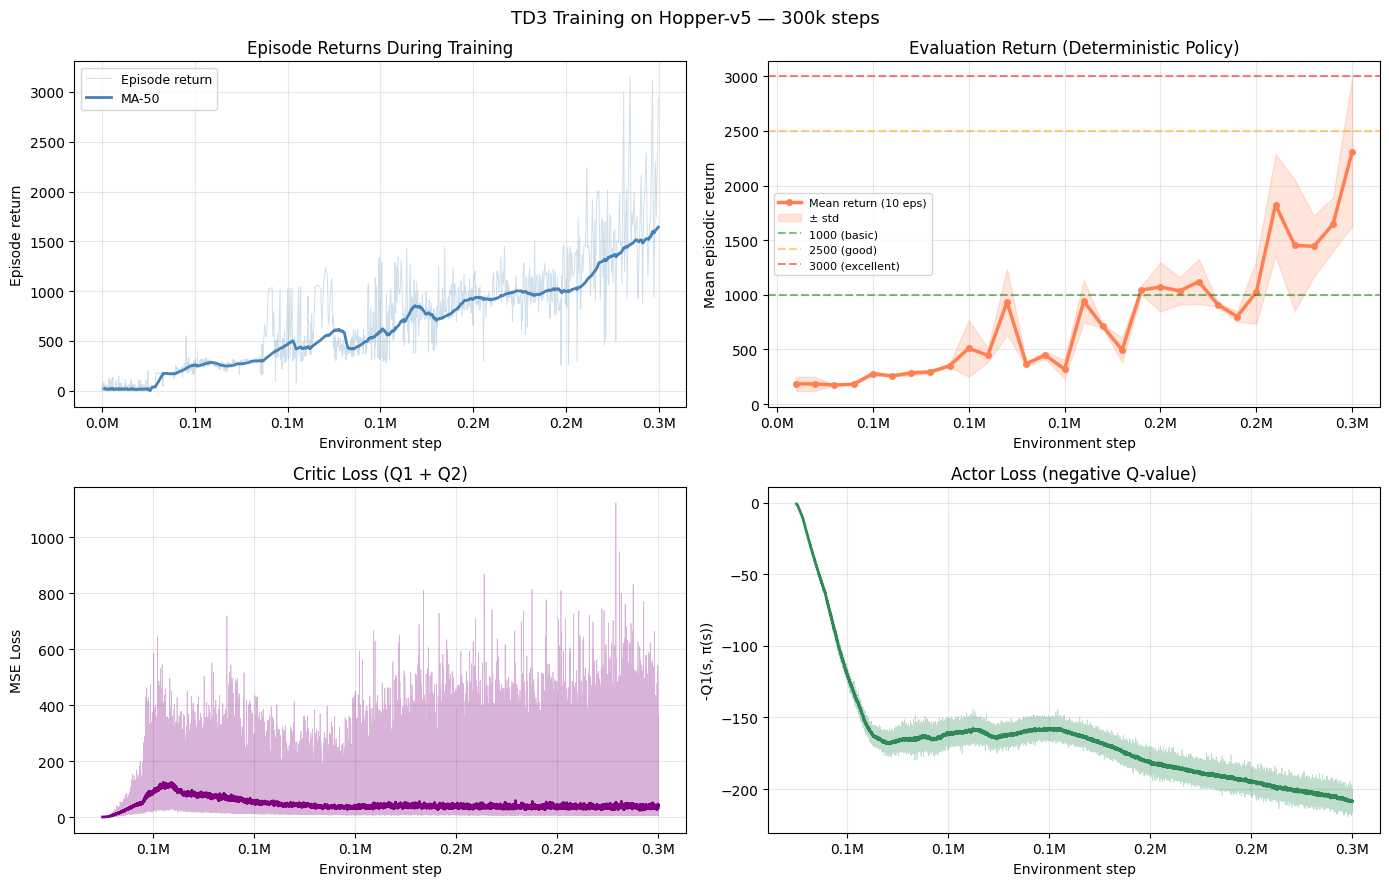

Saved → td3_training.png


In [11]:
def plot_td3_training(history: dict, cfg: dict,
                     save_path: str = "td3_training.png"):
    """
    Generate a 4-panel training dashboard:
    1. Episode returns (raw + smoothed)
    2. Evaluation returns (mean ± std)
    3. Critic loss
    4. Actor loss
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    # ── Panel 1: Episode Returns ──────────────────────────────────────────────
    ax = axes[0, 0]
    steps_ep  = history["episode_steps"]
    returns   = history["episode_returns"]
    ax.plot(steps_ep, returns, alpha=0.25, color="steelblue", lw=0.7, label="Episode return")
    # Smooth with rolling window
    if len(returns) > 50:
        smooth = np.convolve(returns, np.ones(50)/50, mode="valid")
        ax.plot(steps_ep[49:], smooth, color="steelblue", lw=2, label="MA-50")
    ax.set(xlabel="Environment step", ylabel="Episode return",
           title="Episode Returns During Training")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f"{x/1e6:.1f}M"))

    # ── Panel 2: Evaluation Returns ───────────────────────────────────────────
    ax = axes[0, 1]
    eval_steps = history["eval_steps"]
    eval_means = history["eval_returns_mean"]
    eval_stds  = history["eval_returns_std"]
    if eval_steps:
        ax.plot(eval_steps, eval_means, "o-", color="coral", lw=2.5, ms=4,
                label="Mean return (10 eps)")
        ax.fill_between(eval_steps,
                        np.array(eval_means) - np.array(eval_stds),
                        np.array(eval_means) + np.array(eval_stds),
                        color="coral", alpha=0.2, label="± std")
        # Reference line for "solved" threshold (Hopper ~3000 is good)
        ax.axhline(1000, color="green",  linestyle="--", alpha=0.5, lw=1.5, label="1000 (basic)")
        ax.axhline(2500, color="orange", linestyle="--", alpha=0.5, lw=1.5, label="2500 (good)")
        ax.axhline(3000, color="red",    linestyle="--", alpha=0.5, lw=1.5, label="3000 (excellent)")
    ax.set(xlabel="Environment step", ylabel="Mean episodic return",
           title="Evaluation Return (Deterministic Policy)")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f"{x/1e6:.1f}M"))

    # ── Panel 3: Critic Loss ──────────────────────────────────────────────────
    ax = axes[1, 0]
    if history["critic_losses"]:
        loss_steps = history["loss_steps"]
        cl = np.array(history["critic_losses"])
        ax.plot(loss_steps[:len(cl)], cl, alpha=0.3, color="purple", lw=0.5)
        if len(cl) > 200:
            sm = np.convolve(cl, np.ones(200)/200, "valid")
            ax.plot(loss_steps[199:199+len(sm)], sm, color="purple", lw=2)
        ax.set(xlabel="Environment step", ylabel="MSE Loss",
               title="Critic Loss (Q1 + Q2)")
        ax.grid(alpha=0.3)
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f"{x/1e6:.1f}M"))

    # ── Panel 4: Actor Loss ───────────────────────────────────────────────────
    ax = axes[1, 1]
    if history["actor_losses"]:
        # Actor updates every 2 steps → fewer data points
        al = np.array(history["actor_losses"])
        # actor_losses aligns with every-other loss_step
        actor_steps = history["loss_steps"][1::2][:len(al)]
        ax.plot(actor_steps, al, alpha=0.3, color="seagreen", lw=0.5)
        if len(al) > 100:
            sm = np.convolve(al, np.ones(100)/100, "valid")
            ax.plot(actor_steps[99:99+len(sm)], sm, color="seagreen", lw=2)
        ax.set(xlabel="Environment step", ylabel="-Q1(s, π(s))",
               title="Actor Loss (negative Q-value)")
        ax.grid(alpha=0.3)
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f"{x/1e6:.1f}M"))

    plt.suptitle(f"TD3 Training on {cfg['env_name']} — {cfg['total_steps']//1000}k steps",
                 fontsize=13)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {save_path}")


plot_td3_training(history, CFG)

In [12]:
print("Final evaluation (100 episodes, deterministic) …")
final_eval = evaluate_policy(
    agent, CFG["env_name"], seed=CFG["seed"]+9999,
    n_episodes=100
)
print(f"  Mean return : {final_eval['mean']:.2f}")
print(f"  Std         : {final_eval['std']:.2f}")
print(f"  Min         : {final_eval['min']:.2f}")
print(f"  Max         : {final_eval['max']:.2f}")

# ── Results table ─────────────────────────────────────────────────────────────
best_eval = max(history["eval_returns_mean"]) if history["eval_returns_mean"] else 0
best_step = history["eval_steps"][
    np.argmax(history["eval_returns_mean"])
] if history["eval_returns_mean"] else 0

print("\n" + "="*55)
print("TD3 BASELINE RESULTS — Hopper-v5")
print("="*55)
print(f"  Training steps     : {CFG['total_steps']:,}")
print(f"  Final mean return  : {final_eval['mean']:.2f} ± {final_eval['std']:.2f}")
print(f"  Best eval return   : {best_eval:.2f}  (at step {best_step:,})")
print(f"  Episodes trained   : {len(history['episode_returns']):,}")
print("="*55)

# Save summary
summary = {
    "algorithm"       : "TD3",
    "env"             : CFG["env_name"],
    "total_steps"     : CFG["total_steps"],
    "final_mean_return": final_eval["mean"],
    "final_std_return" : final_eval["std"],
    "best_eval_return" : best_eval,
    "best_eval_step"   : best_step,
    "cfg"             : CFG,
    "eval_curve"      : {
        "steps"   : history["eval_steps"],
        "means"   : history["eval_returns_mean"],
        "stds"    : history["eval_returns_std"],
    }
}
with open("rl_phase1_td3_summary.json","w") as f: json.dump(summary, f, indent=2)
print("\nSaved → rl_phase1_td3_summary.json")

Final evaluation (100 episodes, deterministic) …
  Mean return : 2413.32
  Std         : 604.45
  Min         : 1104.45
  Max         : 3128.38

TD3 BASELINE RESULTS — Hopper-v5
  Training steps     : 300,000
  Final mean return  : 2413.32 ± 604.45
  Best eval return   : 2310.39  (at step 300,000)
  Episodes trained   : 2,582

Saved → rl_phase1_td3_summary.json


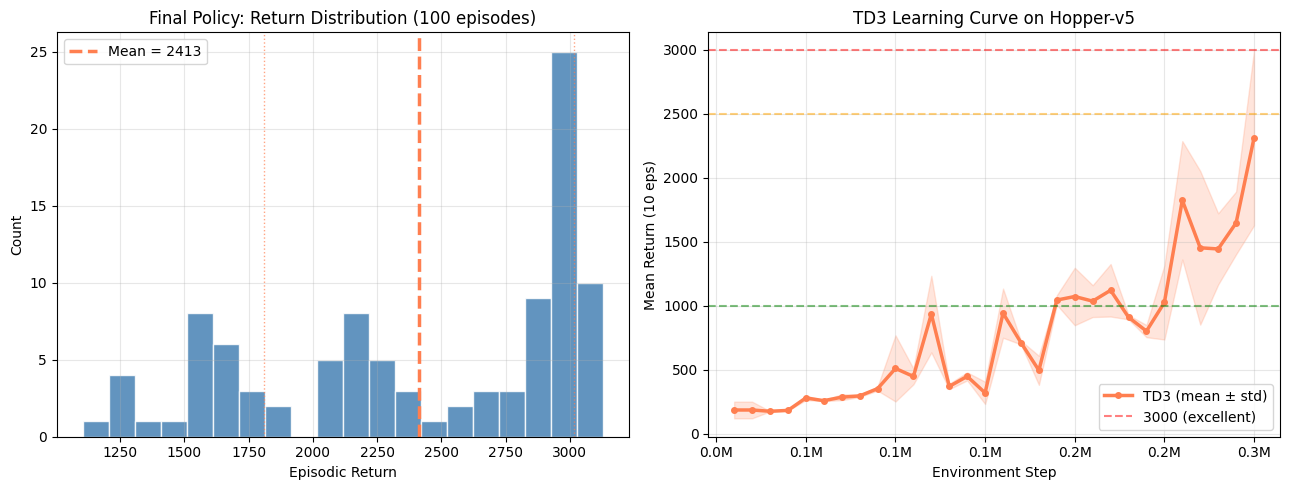

Saved → td3_final_results.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: histogram of final 100-episode returns
ax = axes[0]
ax.hist(final_eval["all_returns"], bins=20, color="steelblue",
        edgecolor="white", alpha=0.85)
ax.axvline(final_eval["mean"], color="coral", lw=2.5, linestyle="--",
           label=f"Mean = {final_eval['mean']:.0f}")
ax.axvline(final_eval["mean"] - final_eval["std"], color="coral",
           lw=1, linestyle=":", alpha=0.7)
ax.axvline(final_eval["mean"] + final_eval["std"], color="coral",
           lw=1, linestyle=":", alpha=0.7)
ax.set(xlabel="Episodic Return", ylabel="Count",
       title="Final Policy: Return Distribution (100 episodes)")
ax.legend(); ax.grid(alpha=0.3)

# Right: learning curve with confidence band
ax = axes[1]
if history["eval_steps"]:
    means = np.array(history["eval_returns_mean"])
    stds  = np.array(history["eval_returns_std"])
    steps = np.array(history["eval_steps"])
    ax.plot(steps, means, "o-", color="coral", lw=2.5, ms=4, label="TD3 (mean ± std)")
    ax.fill_between(steps, means-stds, means+stds, alpha=0.2, color="coral")
    ax.axhline(1000, color="green",  linestyle="--", alpha=0.5, lw=1.5)
    ax.axhline(2500, color="orange", linestyle="--", alpha=0.5, lw=1.5)
    ax.axhline(3000, color="red",    linestyle="--", alpha=0.5, lw=1.5, label="3000 (excellent)")
    ax.set(xlabel="Environment Step", ylabel="Mean Return (10 eps)",
           title="TD3 Learning Curve on Hopper-v5")
    ax.legend(); ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x,_: f"{x/1e6:.1f}M"))

plt.tight_layout()
plt.savefig("td3_final_results.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved → td3_final_results.png")